#### Support Vector Machine
SVM is a powerful supervised algorithm that works best on smaller datasets but on complex ones. SVM can be used for both Regression and Classification tasks, but generally, they work best in classification problem.

Logistic regression is probalisitic approach whereas SVM is statistical approach. Logistic regression and SVM without kernel have similer performance.

> Types of SVM are Linear and Non-Linear

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

In [9]:
iris = load_iris()
iris.data[:4]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2]])

In [12]:
iris["feature_names"]

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [27]:
dataset = pd.DataFrame(iris.data,columns=iris.feature_names)
dataset["target"] = iris.target
dataset.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [28]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [51]:
dataset[dataset["target"] == 0].head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [52]:
dataset["flower_name"] = dataset["target"].apply(lambda x: iris.target_names[x])

In [56]:
dataset.to_csv("iris_data_cleaned.csv")

In [170]:
setosa = dataset[dataset["target"]==0]
versicolor = dataset[dataset["target"]==1]
virginica = dataset[dataset["target"]==2]

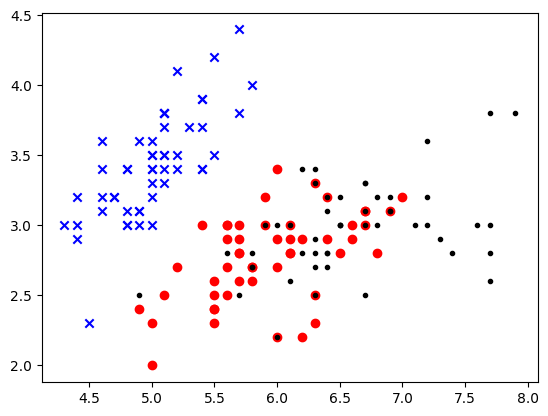

In [166]:
plt.scatter(setosa["sepal length (cm)"],setosa["sepal width (cm)"],color="blue",marker="x")
plt.scatter(versicolor["sepal length (cm)"],versicolor["sepal width (cm)"],color="red",marker="o")
plt.scatter(virginica["sepal length (cm)"],virginica["sepal width (cm)"],color="black",marker=".")

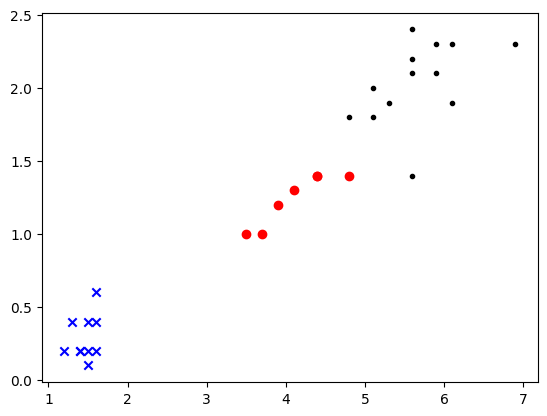

In [161]:
plt.scatter(setosa["petal length (cm)"],setosa["petal width (cm)"],color="blue",marker="x")
plt.scatter(versicolor["petal length (cm)"],versicolor["petal width (cm)"],color="red",marker="o")
plt.scatter(virginica["petal length (cm)"],virginica["petal width (cm)"],color="black",marker=".")

In [73]:
X = dataset.drop(["target","flower_name"],axis="columns")
y = dataset["target"]

In [76]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

In [145]:
Model_SVC = SVC(kernel="linear",gamma=30)

In [146]:
Model_SVC.fit(X_train,y_train)

SVC(gamma=30, kernel='linear')

In [147]:
y_predicted = Model_SVC.predict(X_test)

In [148]:
Model_SVC.score(X_test,y_test)

1.0

In [149]:
Model_SVC.score(X_train,y_train)

0.9916666666666667

#### Make a predicted dataset 

In [154]:
predicted_dataset = X_test
predicted_dataset["target"] = y_predicted
predicted_dataset.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
16,5.4,3.9,1.3,0.4,0
149,5.9,3.0,5.1,1.8,2
11,4.8,3.4,1.6,0.2,0
48,5.3,3.7,1.5,0.2,0
79,5.7,2.6,3.5,1.0,1


In [155]:
predicted_dataset["Flower_Name"] = predicted_dataset["target"].apply(lambda x:  iris.target_names[x])
predicted_dataset.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,Flower_Name
16,5.4,3.9,1.3,0.4,0,setosa
149,5.9,3.0,5.1,1.8,2,virginica
11,4.8,3.4,1.6,0.2,0,setosa
48,5.3,3.7,1.5,0.2,0,setosa
79,5.7,2.6,3.5,1.0,1,versicolor


#### Seperate Predicted Dataset Flowers

In [167]:
predicted_setosa = predicted_dataset[predicted_dataset["target"]==0]
predicted_versicolor = predicted_dataset[predicted_dataset["target"]==1]
predicted_virginica = predicted_dataset[predicted_dataset["target"]==2]

#### Visualize and Compare

##### Actual

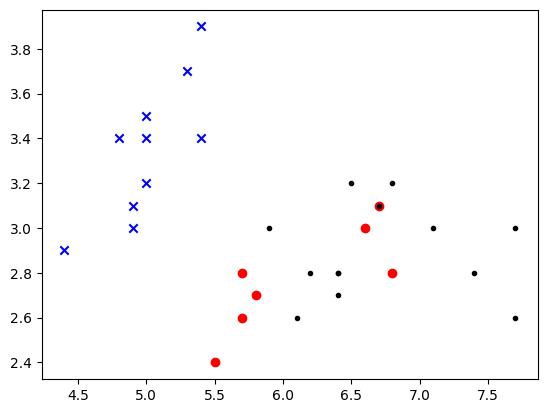

In [176]:
plt.scatter(predicted_setosa["sepal length (cm)"],predicted_setosa["sepal width (cm)"],color="blue",marker="x")
plt.scatter(predicted_versicolor["sepal length (cm)"],predicted_versicolor["sepal width (cm)"],color="red",marker="o")
plt.scatter(predicted_virginica["sepal length (cm)"],predicted_virginica["sepal width (cm)"],color="black",marker=".")

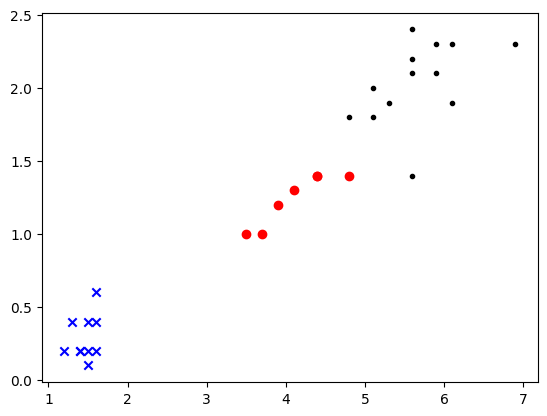

In [174]:
plt.scatter(predicted_setosa["petal length (cm)"],predicted_setosa["petal width (cm)"],color="blue",marker="x")
plt.scatter(predicted_versicolor["petal length (cm)"],predicted_versicolor["petal width (cm)"],color="red",marker="o")
plt.scatter(predicted_virginica["petal length (cm)"],predicted_virginica["petal width (cm)"],color="black",marker=".")